# ==========================================
# OASIS INFOBYTE - DATA SCIENCE INTERNSHIP
# TASK 2: Sales Prediction
# Author: Muhammad Farhan
# Track: Data Science
# Repo Name: OIBSIP
# ==========================================

### ==============================================================================
### SECTION 1: DATA LOADING, STRUCTURE INSPECTION & QUALITY CHECKS
### ==============================================================================
### Objective: Load the raw Advertising dataset, convert it to a structured DataFrame,
### check for missing values, and analyze basic statistical metrics.
### Import required libraries

In [1]:
import warnings
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
data = pd.read_csv('Advertising.csv')

In [3]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
data = data.drop('Unnamed: 0',axis=1)
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [7]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### ==============================================================================
### SECTION 2: VISUAL EXPLORATORY DATA ANALYSIS (EDA)
### ==============================================================================

In [8]:
import os
os.makedirs('images', exist_ok=True)

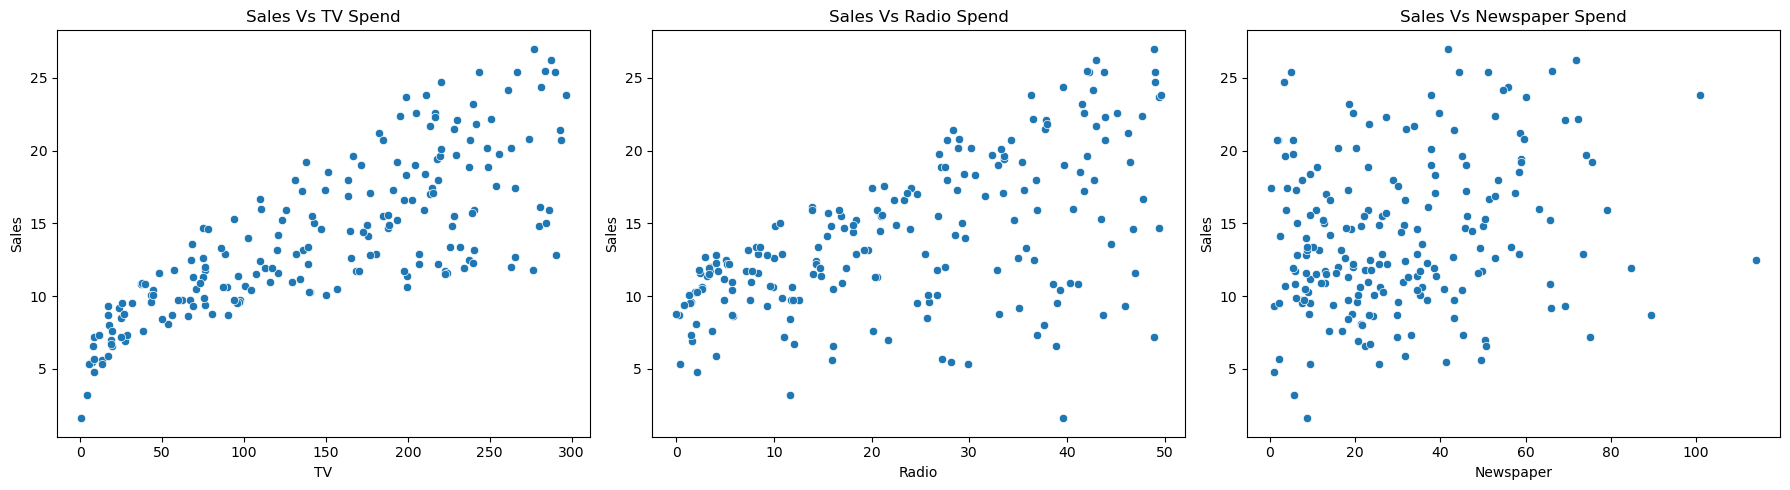

In [9]:
fig,axes = plt.subplots(1,3, figsize=(18,5))

sns.scatterplot(data= data , x='TV',y='Sales',  ax=axes[0])
axes[0].set_title('Sales Vs TV Spend')
    
sns.scatterplot(data= data , x='Radio',y='Sales',  ax=axes[1])
axes[1].set_title('Sales Vs Radio Spend')

sns.scatterplot(data= data , x='Newspaper',y='Sales',  ax=axes[2])
axes[2].set_title('Sales Vs Newspaper Spend')

plt.tight_layout()

plt.savefig('images/sales_scatter_plots.png' , dpi=150 , bbox_inches='tight')
plt.show()

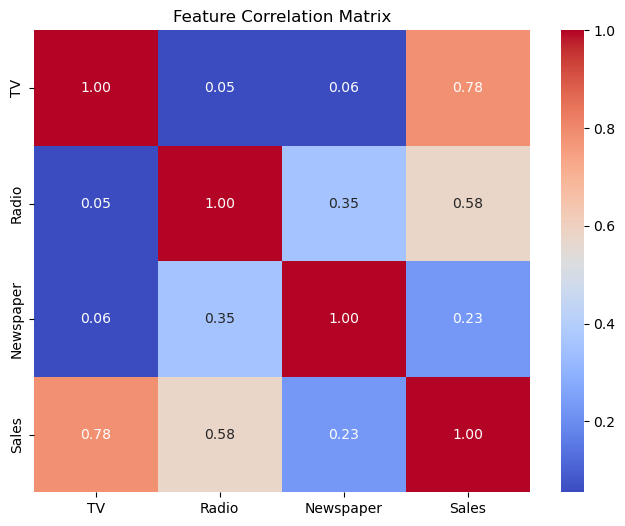

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(data.corr(), annot=True, cmap='coolwarm' , fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.savefig('images/sales_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

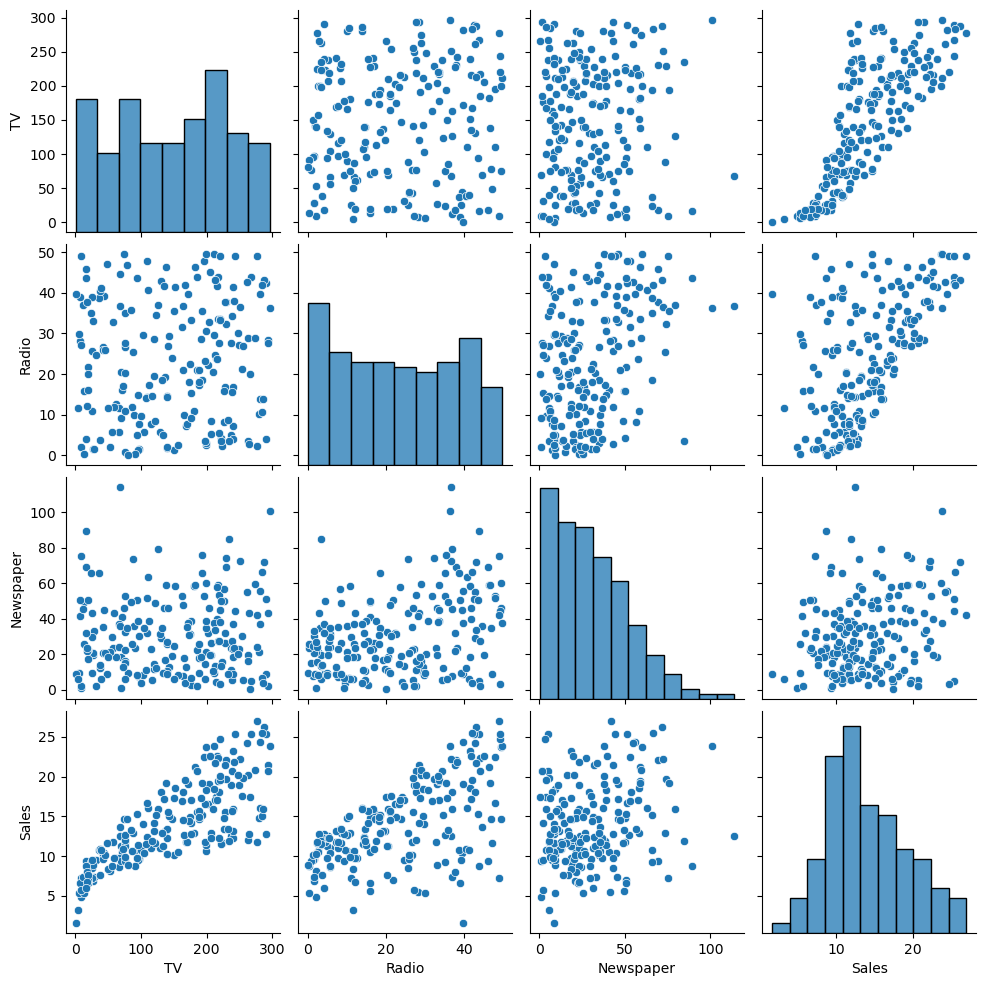

In [11]:
sns.pairplot(data)
plt.savefig('images/sales_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

### ==============================================================================
### Section 3: DATA PREPROCESSING & TRAIN-TEST SPLIT
### ==============================================================================

In [12]:
X = data.drop('Sales',axis=1)
y = data['Sales']

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3 , random_state=42)

In [15]:
print("=== TRAIN-TEST SPLIT SUMMARY ===")
print(f"Total Dataset Size : {len(data)} samples")
print(f"Training Set Size  : {X_train.shape[0]} samples ({X_train.shape[0]/len(data)*100:.0f}%)")
print(f"Testing Set Size   : {X_test.shape[0]} samples ({X_test.shape[0]/len(data)*100:.0f}%)")


=== TRAIN-TEST SPLIT SUMMARY ===
Total Dataset Size : 200 samples
Training Set Size  : 140 samples (70%)
Testing Set Size   : 60 samples (30%)


### ==============================================================================
### Section 4: MODEL TRAINING & EVALUATION (Linear Regression)
### ==============================================================================

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
model = LinearRegression()

In [18]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred_train = model.predict(X_train)

In [20]:
y_pred_test = model.predict(X_test)

In [21]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [0.04405928 0.1992875  0.00688245]
Intercept: 2.70894909251591


In [22]:
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R2 Score:", r2_score(y_test, y_pred_test))

MAE: 1.5116692224549084
MSE: 3.796797236715217
RMSE: 1.9485372043446378
R2 Score: 0.8609466508230369


In [23]:
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2 Score:", r2_score(y_train, y_pred_train))

MAE: 1.1581502948072528
MSE: 2.4793551789057866
RMSE: 1.574596830590544
R2 Score: 0.9055159502227753


### ==============================================================================
### Section 4 (CONTINUED): Coefficient Analysis & Residual Plot VISUALIZATION
### ==============================================================================

In [24]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

     Feature  Coefficient
1      Radio     0.199287
0         TV     0.044059
2  Newspaper     0.006882


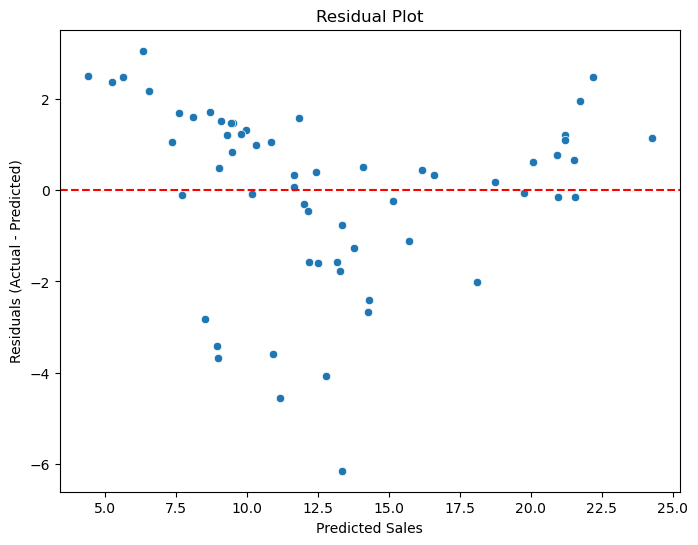

In [27]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_test, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.savefig('images/sales_residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()